# Study 9 (Supplementary) - Deep Learning Baseline (LSTM)

Reviewer point: a 2026 submission should compare against a modern sequence model, not only persistence,
logistic regression, and gradient boosting. This notebook adds a recurrent (LSTM) baseline for episode
onset forecasting and evaluates it on the same task, split, and dropout protocol as the main study, next
to the twin and the gradient boosting model.

Task and data: Nordic PM2.5 + ERA5, 6 h steps, onset of a WHO-15 exceedance within 24 h, interleaved
even/odd-month holdout. The LSTM sees a lookback window of the multimodal features ending at the decision
time. Under sensor failure the LSTM, like the other learned baselines, receives the last observed
pollutant value carried forward.

Requirements: `pip install torch` (CPU is sufficient) in addition to numpy, pandas, scikit-learn,
matplotlib. Nothing is executed in the repository copy; run it to produce the numbers.

In [1]:
import numpy as np, pandas as pd, math, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import torch, torch.nn as nn
torch.manual_seed(0); np.random.seed(0)
OUT=Path("../outputs/study9_lstm"); OUT.mkdir(parents=True,exist_ok=True)
plt.rcParams.update({"figure.dpi":130,"savefig.dpi":150,"font.size":11,"axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
STEP=6; H=4; TAU=15.0; L=8   # lookback window of 8 six-hour steps (48 h)

pm=pd.read_csv("../data/openaq_regional/regional_pm25.csv"); pm["datetime"]=pd.to_datetime(pm["datetime"],utc=True)
pm["name"]=pm.station.str.split("::").str[1]; pm=pm.dropna(subset=["value"]); pm=pm[(pm.value>=0)&(pm.value<1500)]
met=pd.read_csv("../data/era5/era5_regional.csv",usecols=["datetime","station","wind_speed","blh","t2m"])
met["datetime"]=pd.to_datetime(met["datetime"],utc=True); met=met.rename(columns={"station":"name"})
yrs=pm.groupby("station")["datetime"].agg(lambda s:(s.max()-s.min()).days/365.25); pm=pm[pm.station.isin(yrs[yrs>=2].index)].copy()
print("stations",pm.station.nunique())

stations 21


## Per-station feature series and sequence windows

Features per 6 h step: self referenced PM2.5, wind, boundary layer height, temperature, and cyclical
hour-of-day and day-of-year encodings. Normalisation statistics are estimated on the training months only.
A prediction point is a currently-clean step; its input is the preceding window of length $L$, and its
label is the onset indicator over the next 24 h.

In [2]:
FEATS=["zpm","zwind","zblh","ztemp","hour_sin","hour_cos","doy_sin","doy_cos"]; D=len(FEATS)
ST={}
for st,g in pm.groupby("station"):
    name=g["name"].iloc[0]
    s=g.set_index("datetime").value.resample(f"{STEP}h").mean()
    mg=met[met.name==name].set_index("datetime")[["wind_speed","blh","t2m"]].resample(f"{STEP}h").mean()
    idx=s.index; A=pd.DataFrame({"pm":s}).join(mg).reindex(idx); tm=(idx.month%2==0)
    def z(col,log=False):
        v=np.log1p(np.clip(A[col].to_numpy(),0,None)) if log else A[col].to_numpy()
        mu,sd=np.nanmean(v[tm]),np.nanstd(v[tm])+1e-9; return (v-mu)/sd
    zpm=z("pm",log=True); zw=z("wind_speed"); zb=z("blh"); zt=z("t2m")
    hr=idx.hour.to_numpy(); doy=idx.dayofyear.to_numpy()
    F=np.column_stack([zpm,zw,zb,zt,np.sin(2*np.pi*hr/24),np.cos(2*np.pi*hr/24),
                       np.sin(2*np.pi*doy/365),np.cos(2*np.pi*doy/365)])
    ST[st]=dict(F=F,v=A["pm"].to_numpy(),tm=tm,zpm=zpm)

def build_windows(mask_pm=None, rng=None, pdrop=0.0):
    '''Return X[N,L,D], y[N], split[N]. If pdrop>0, mask PM channel per step and forward fill.'''
    Xs=[];ys=[];sp=[]
    for st,d in ST.items():
        F=d["F"].copy(); v=d["v"]; tm=d["tm"]; T=len(v)
        if pdrop>0:
            miss=rng.random(T)<pdrop; pmc=F[:,0].copy()
            for i in range(T):
                if miss[i]: pmc[i]=pmc[i-1] if i>0 else pmc[i]   # forward fill PM channel
            F[:,0]=pmc
        F=np.nan_to_num(F,nan=0.0)
        for t in range(L-1,T-H):
            if np.isnan(v[t]) or v[t]>=TAU: continue
            fut=v[t+1:t+1+H]
            if np.all(np.isnan(fut)): continue
            Xs.append(F[t-L+1:t+1]); ys.append(int(np.nanmax(fut)>=TAU)); sp.append(0 if tm[t] else 1)
    return np.asarray(Xs,dtype=np.float32),np.asarray(ys,dtype=np.float32),np.asarray(sp)

X,y,sp=build_windows()
Xtr,ytr=X[sp==0],y[sp==0]; Xte,yte=X[sp==1],y[sp==1]
print("windows",X.shape,"| train",len(ytr),"| test",len(yte),"| onset prevalence",round(y.mean(),3))

windows (92800, 8, 8) | train 44660 | test 48140 | onset prevalence 0.073


## LSTM model and training

In [3]:
class LSTMClf(nn.Module):
    def __init__(self,d=D,h=48):
        super().__init__(); self.lstm=nn.LSTM(d,h,batch_first=True); self.fc=nn.Linear(h,1)
    def forward(self,x):
        o,_=self.lstm(x); return self.fc(o[:,-1,:]).squeeze(-1)

def train_lstm(Xtr,ytr,epochs=15,bs=512,lr=1e-3):
    dev="cuda" if torch.cuda.is_available() else "cpu"
    model=LSTMClf().to(dev)
    pos=ytr.sum(); neg=len(ytr)-pos; pw=torch.tensor([neg/max(pos,1)],dtype=torch.float32,device=dev)
    lossf=nn.BCEWithLogitsLoss(pos_weight=pw); opt=torch.optim.Adam(model.parameters(),lr=lr)
    Xt=torch.tensor(Xtr,device=dev); yt=torch.tensor(ytr,device=dev); n=len(yt)
    for ep in range(epochs):
        model.train(); perm=torch.randperm(n,device=dev); tot=0.0
        for i in range(0,n,bs):
            idx=perm[i:i+bs]; opt.zero_grad(); out=model(Xt[idx]); loss=lossf(out,yt[idx]); loss.backward(); opt.step(); tot+=loss.item()*len(idx)
        print(f"  epoch {ep+1:2d}  loss {tot/n:.4f}")
    return model,dev

def predict_lstm(model,dev,Xin,bs=1024):
    model.eval(); outs=[]
    with torch.no_grad():
        Xt=torch.tensor(Xin,device=dev)
        for i in range(0,len(Xt),bs):
            outs.append(torch.sigmoid(model(Xt[i:i+bs])).cpu().numpy())
    return np.concatenate(outs)

model,dev=train_lstm(Xtr,ytr)
p_lstm=predict_lstm(model,dev,Xte)
print(f"\nLSTM complete-data: AUROC {roc_auc_score(yte,p_lstm):.3f}  AUPRC {average_precision_score(yte,p_lstm):.3f}")

  epoch  1  loss 1.1395
  epoch  2  loss 1.0238
  epoch  3  loss 1.0043
  epoch  4  loss 0.9914
  epoch  5  loss 0.9831
  epoch  6  loss 0.9765
  epoch  7  loss 0.9703
  epoch  8  loss 0.9645
  epoch  9  loss 0.9594
  epoch 10  loss 0.9523
  epoch 11  loss 0.9484
  epoch 12  loss 0.9428
  epoch 13  loss 0.9352
  epoch 14  loss 0.9267
  epoch 15  loss 0.9238

LSTM complete-data: AUROC 0.815  AUPRC 0.280


## Reference models on the same test set (twin and gradient boosting)

For a like-for-like comparison, the fuller twin and the gradient boosting model are evaluated on the same
prediction points. Feature vectors for gradient boosting use the current step plus two lags and trend, as
in the main study.

In [4]:
# gradient boosting on flat features derived from the same windows (current + lags + trend + met + time)
def flat_feats(X):
    # X[N,L,D]; take last step and lags of the PM channel
    zpm=X[:,-1,0]; zpm_l1=X[:,-2,0]; zpm_l2=X[:,-3,0]; zpm_tr=X[:,-1,0]-X[:,-3,0]
    last=X[:,-1,:]  # zpm,zw,zb,zt,hs,hc,ds,dc
    return np.column_stack([zpm,zpm_l1,zpm_l2,zpm_tr,last[:,1],last[:,2],last[:,3],last[:,4],last[:,5],last[:,6],last[:,7]])
gbm=HistGradientBoostingClassifier(max_iter=300,learning_rate=0.05,max_depth=4,l2_regularization=1.0,random_state=0)
gbm.fit(flat_feats(Xtr),ytr); p_gbm=gbm.predict_proba(flat_feats(Xte))[:,1]

# twin (fuller, pure python) risk at each prediction point, recalibrated on train predictions
K=5; LEV=[i/(K-1) for i in range(K)]; SDL=[1.0+0.5*l for l in LEV]; LOGC=0.5*math.log(2*math.pi); LGC=[-LOGC-math.log(s) for s in SDL]
def lgv(z): return [LGC[k]-0.5*((z-2.0*LEV[k])/SDL[k])**2 for k in range(K)]
def twin_seq(X):
    # run the filter along each window; return risk at the last step
    W=(1.0,0.5,0.5,0.4); out=np.empty(len(X))
    for n in range(len(X)):
        logb=[-3*k for k in range(K)]; m=max(logb); ss=sum(math.exp(x-m) for x in logb); logb=[x-m-math.log(ss) for x in logb]
        for t in range(X.shape[1]):
            mb=max(logb); b=[math.exp(x-mb) for x in logb]; sb=sum(b); b=[x/sb for x in b]
            el=sum(b[k]*LEV[k] for k in range(K)); up=0.25; pdn=0.05 if el>0.4 else 0.15; bp=[0.0]*K
            for k in range(K):
                u=up if k<K-1 else 0.0; d=pdn if k>0 else 0.0; bp[k]+=b[k]*(1-u-d)
                if k<K-1: bp[k+1]+=b[k]*u
                if k>0: bp[k-1]+=b[k]*d
            logbp=[math.log(x+1e-12) for x in bp]
            for j,w,inv in [(0,W[0],1),(1,W[1],-1),(2,W[2],-1),(3,W[3],-1)]:
                z=X[n,t,j]; lv=lgv(inv*z); logbp=[logbp[k]+w*lv[k] for k in range(K)]
            m2=max(logbp); s2=math.log(sum(math.exp(x-m2) for x in logbp)); logb=[x-m2-s2 for x in logbp]
        eb=[math.exp(x) for x in logb]; out[n]=sum(eb[k]*LEV[k] for k in range(K))
    return out
r_tr=twin_seq(Xtr); r_te=twin_seq(Xte)
def platt_fit(x,y,ep=3000,lr=.3):
    x=np.asarray(x,float);mu,sd=x.mean(),x.std()+1e-9;xs=(x-mu)/sd;w=0.;bi=0.
    for _ in range(ep): p=1/(1+np.exp(-(w*xs+bi)));w-=lr*np.mean((p-y)*xs);bi-=lr*np.mean(p-y)
    return lambda z:1/(1+np.exp(-(w*((np.asarray(z,float)-mu)/sd)+bi)))
ftw=platt_fit(r_tr,ytr); p_twin=ftw(r_te)
import pandas as pd
tab=pd.DataFrame({
  "model":["twin (recalibrated)","gradient boosting","LSTM"],
  "AUROC":[roc_auc_score(yte,p_twin),roc_auc_score(yte,p_gbm),roc_auc_score(yte,p_lstm)],
  "AUPRC":[average_precision_score(yte,p_twin),average_precision_score(yte,p_gbm),average_precision_score(yte,p_lstm)]}).set_index("model")
print(tab.round(3).to_string())

                     AUROC  AUPRC
model                            
twin (recalibrated)  0.794  0.255
gradient boosting    0.815  0.269
LSTM                 0.815  0.280


## Robustness under pollutant dropout

The PM channel is masked at each step with probability $p$ and forward filled for the learned models
(LSTM, gradient boosting); the twin marginalises. Onset AUROC is reported against $p$.

 dropout  gradient_boosting  twin  lstm
    0.00              0.815 0.794 0.815
    0.40              0.796 0.781 0.798
    0.70              0.771 0.762 0.769
    0.85              0.745 0.739 0.741


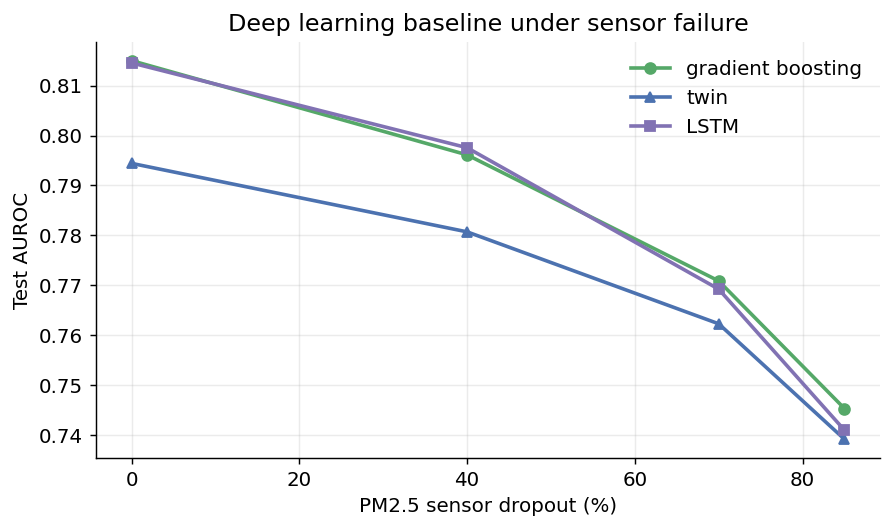

In [5]:
def eval_dropout(p,seed):
    rng=np.random.default_rng(seed)
    Xp,yp,spp=build_windows(rng=rng,pdrop=p)
    Xte_p,yte_p=Xp[spp==1],yp[spp==1]
    a_lstm=roc_auc_score(yte_p,predict_lstm(model,dev,Xte_p))
    a_gbm=roc_auc_score(yte_p,gbm.predict_proba(flat_feats(Xte_p))[:,1])
    a_twin=roc_auc_score(yte_p,ftw(twin_seq(Xte_p)))
    return a_gbm,a_twin,a_lstm
ps=[0.0,0.4,0.7,0.85]; G=[];T=[];Lm=[]
for p in ps:
    seeds=[0] if p==0 else [0,1]
    r=np.mean([eval_dropout(p,s) for s in seeds],axis=0); G.append(r[0]);T.append(r[1]);Lm.append(r[2])
rob=pd.DataFrame({"dropout":ps,"gradient_boosting":G,"twin":T,"lstm":Lm}); print(rob.round(3).to_string(index=False))
fig,ax=plt.subplots(figsize=(7,4.2)); xp=[p*100 for p in ps]
ax.plot(xp,G,"-o",color="#55A868",lw=2,label="gradient boosting")
ax.plot(xp,T,"-^",color="#4C72B0",lw=2,label="twin")
ax.plot(xp,Lm,"-s",color="#8172B3",lw=2,label="LSTM")
ax.set_xlabel("PM2.5 sensor dropout (%)"); ax.set_ylabel("Test AUROC"); ax.set_title("Deep learning baseline under sensor failure"); ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(OUT/"fig1_lstm_robustness.png",bbox_inches="tight"); plt.show()